In [ ]:
!pip install pyvi
!pip install langdetect
!pip install wordcloud
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 14.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=65d5b13591f3b75a93ad38de7a012bbab939d031b1698259ff339436c05780bf
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 70.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import re
import warnings
warnings.filterwarnings('ignore')

import time
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from langdetect import detect
from wordcloud import WordCloud
from sklearn.decomposition import TruncatedSVD
from gensim import corpora, models, similarities
from pyvi.ViTokenizer import tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import linear_kernel, cosine_similarity

# Read and overview data

In [ ]:
data = pd.read_excel('/content/drive/MyDrive/DL07_K308_PhamNamAn_CaoThanhBang/Project_2/data_motobikes.xlsx')
data.head(3)

,id,Tiêu đề,Giá,Khoảng giá min,Khoảng giá max,Địa chỉ,Mô tả chi tiết,Thương hiệu,Dòng xe,Năm đăng ký,Số Km đã đi,Tình trạng,Loại xe,Dung tích xe,Xuất xứ,Chính sách bảo hành,Trọng lượng,Href
0,1,"Bán Vespa Sprint 125cc 2024 xanh dương, xe đẹp...",66.000.000 đ,72.53 tr,85.14 tr,"Phường Bến Thành, Quận 1, Tp Hồ Chí Minh",Bán xe #Vespa Sprint 125cc. Mua mới tại #Topco...,Piaggio,Vespa,2024,14000,Đã sử dụng,Tay ga,100 - 175 cc,Đang cập nhật,Bảo hành hãng,> 50 kg,https://xe.chotot.com/mua-ban-xe-may-quan-1-tp...
1,2,🔥🔥SH 150i Thắng ABS 2019 BSTP Chính Chủ,79.500.000 đ,62.76 tr,73.68 tr,"Phường Tân Định, Quận 1, Tp Hồ Chí Minh","_Bán SH 150i Thắng ABS 2019 Xám Bạc, Úp Team X...",Honda,SH,2019,28000,Đã sử dụng,Tay ga,100 - 175 cc,Đang cập nhật,Bảo hành hãng,> 50 kg,https://xe.chotot.com/mua-ban-xe-may-quan-1-tp...
2,3,CC Vision Thể Thao 2023 Đen+bộ đèn Demi audi A7,37.000.000 đ,28 tr,32.86 tr,"Phường Cầu Kho, Quận 1, Tp Hồ Chí Minh",Chính chủ bán Vision phiên bản Thể Thao 2023 Đ...,Honda,Vision,2023,12000,Đã sử dụng,Tay ga,100 - 175 cc,Đang cập nhật,Bảo hành hãng,> 50 kg,https://xe.chotot.com/mua-ban-xe-may-quan-1-tp...


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7208 entries, 0 to 7207
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   7208 non-null   int64 
 1   Tiêu đề              7207 non-null   object
 2   Giá                  7206 non-null   object
 3   Khoảng giá min       7006 non-null   object
 4   Khoảng giá max       7011 non-null   object
 5   Địa chỉ              7167 non-null   object
 6   Mô tả chi tiết       7208 non-null   object
 7   Thương hiệu          7205 non-null   object
 8   Dòng xe              7205 non-null   object
 9   Năm đăng ký          7208 non-null   object
 10  Số Km đã đi          7208 non-null   int64 
 11  Tình trạng           7208 non-null   object
 12  Loại xe              7208 non-null   object
 13  Dung tích xe         7208 non-null   object
 14  Xuất xứ              7208 non-null   object
 15  Chính sách bảo hành  7207 non-null   object
 16  Trọng 

In [ ]:
data['title'] = data['Tiêu đề']
data['description'] = data['Mô tả chi tiết']
data = data[['id', 'title', 'description', 'Dòng xe']]

In [ ]:
data.head(3)

,id,title,description,Dòng xe
0,1,"Bán Vespa Sprint 125cc 2024 xanh dương, xe đẹp...",Bán xe #Vespa Sprint 125cc. Mua mới tại #Topco...,Vespa
1,2,🔥🔥SH 150i Thắng ABS 2019 BSTP Chính Chủ,"_Bán SH 150i Thắng ABS 2019 Xám Bạc, Úp Team X...",SH
2,3,CC Vision Thể Thao 2023 Đen+bộ đèn Demi audi A7,Chính chủ bán Vision phiên bản Thể Thao 2023 Đ...,Vision


In [ ]:
for desc in data['description']:
  print(desc)


Bán xe #Vespa Sprint 125cc. Mua mới tại #Topcom 01/2024, Xe chính chủ. Chạy được 14.000km. Giá: 66tr(TL). Anh/chị quan tâm nhắn Zalo số: ***. Công chứng Hợp đồng mua bán trong ngày.
_Bán SH 150i Thắng ABS 2019 Xám Bạc, Úp Team Xám Xi Măng.
_Xe nhà sử dụng kỹ ít đi, chính chủ, biển số thành phố
_Xe mới keng, Máy móc nguyên zin, êm bốc, ae qua xe xem test thoải mái
_Mua bán tại nhà, sang tên ký giấy 1 nốt nhạc
_Xem Xe Tại Nhà Tân Sơn Nhì, P Tân Sơn Nhì , Q Tân Phú
Chính chủ bán Vision phiên bản Thể Thao 2023 Đen
Xe mua chính hãng tháng 10/2023, bảo dưỡng đầy đủ, xe gia đình đi giữ gìn.
Xe đã độ lên đèn Demi led audi A7 và Đèn hậu led audi A7 (giá thị trường 5tr)
(còn nguyên đèn mới zin theo xe)
Liên hệ chính chủ 09xau xau 5 7 năm 3 sáu 7
XE CÁ NHÂN BÁN - XE DO EM ĐỨNG TÊN CHÍNH CHỦ.
Chi Tiết hình ảnh xe đã có đủ. Cần thì liên hệ em.
Sản phẩm theo xe zin còn ( Kính, Bao tay, cảng sau, Chìa khóa còn đủ )
CÓ FIX THÊM CHO ANH CHỊ VỀ SƠN DẬM LẠI.
Xem xe chi tiết Q

In [ ]:
for i in range(20):
  print(f"{i}/ {data['description'][i]}")

0/ Bán xe #Vespa Sprint 125cc. Mua mới tại #Topcom 01/2024, Xe chính chủ. Chạy được 14.000km. Giá: 66tr(TL). Anh/chị quan tâm nhắn Zalo số: ***. Công chứng Hợp đồng mua bán trong ngày.
1/ _Bán SH 150i Thắng ABS 2019 Xám Bạc, Úp Team Xám Xi Măng.
_Xe nhà sử dụng kỹ ít đi, chính chủ, biển số thành phố
_Xe mới keng, Máy móc nguyên zin, êm bốc, ae qua xe xem test thoải mái
_Mua bán tại nhà, sang tên ký giấy 1 nốt nhạc
_Xem Xe Tại Nhà Tân Sơn Nhì, P Tân Sơn Nhì , Q Tân Phú
2/ Chính chủ bán Vision phiên bản Thể Thao 2023 Đen
Xe mua chính hãng tháng 10/2023, bảo dưỡng đầy đủ, xe gia đình đi giữ gìn.
Xe đã độ lên đèn Demi led audi A7 và Đèn hậu led audi A7 (giá thị trường 5tr)
(còn nguyên đèn mới zin theo xe)
Liên hệ chính chủ 09xau xau 5 7 năm 3 sáu 7
3/ XE CÁ NHÂN BÁN - XE DO EM ĐỨNG TÊN CHÍNH CHỦ.
Chi Tiết hình ảnh xe đã có đủ. Cần thì liên hệ em.
Sản phẩm theo xe zin còn ( Kính, Bao tay, cảng sau, Chìa khóa còn đủ )
CÓ FIX THÊM CHO ANH CHỊ VỀ SƠN DẬM LẠI.
Xem xe

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7208 entries, 0 to 7207
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           7208 non-null   int64 
 1   title        7207 non-null   object
 2   description  7208 non-null   object
 3   Dòng xe      7205 non-null   object
dtypes: int64(1), object(3)
memory usage: 225.4+ KB


In [ ]:
data.dropna(inplace=True)

In [ ]:
data.duplicated().any()

np.False_

# Preprocessing data

In [ ]:
def load_dict(path:str):
  dict_results = {}
  with open(path, 'r') as f:
    file = f.read()
  file = file.split('\n')
  for line in file:
    v, k = line.split('\t')
    dict_results[v] = k
  return dict_results

def load_list(path:str):
  with open(path, 'r') as f:
    file = f.read()
  file = file.split('\n')
  return (file)

In [ ]:
dict_teencode = load_dict('/content/drive/MyDrive/DL07_K308_PhamNamAn_CaoThanhBang/Project_2/files/teencode.txt')
lst_wrong_txt = load_list('/content/drive/MyDrive/DL07_K308_PhamNamAn_CaoThanhBang/Project_2/files/wrong-word.txt')
lst_stopwords = load_list('/content/drive/MyDrive/DL07_K308_PhamNamAn_CaoThanhBang/Project_2/files/vietnamese-stopwords.txt')
dict_emoji = load_dict('/content/drive/MyDrive/DL07_K308_PhamNamAn_CaoThanhBang/Project_2/files/emojicon.txt')
dict_translate = load_dict('/content/drive/MyDrive/DL07_K308_PhamNamAn_CaoThanhBang/Project_2/files/english-vnmese.txt')
lst_stopwords.append('xe')

In [ ]:
# Compile regex
url_regex = re.compile(r'http\S+|www\S+')
# Regex này sẽ xóa số và các dấu câu phổ biến
punct_regex_v2 = r'[!"#$%&\'()*+,/:;<=>?@\[\]\\^`{|}~]'

In [ ]:
def preprocess_text(description: str):

    if not isinstance(description, str):
        return "" # Xử lý các giá trị không phải là chuỗi (ví dụ: NaN)

    # Bước 1: Chuẩn hóa cơ bản
    text = description.lower() # Chuyển về chữ thường
    text = re.sub(url_regex, ' ', text) # Xóa URLs

    # Bước 2: Dịch Tiếng Anh (Tùy chọn, có thể giữ)
    # for eng, vie in dict_translate.items():
    #    text = re.sub(r'\b' + re.escape(eng) + r'\b', f' {vie} ', text)

    # Bước 3: Thay thế Emojis
    for emoji, meaning in dict_emoji.items():
        text = text.replace(emoji, f' {meaning} ')

    # Bước 4: Thay thế Teencode
    for code, meaning in dict_teencode.items():
        text = re.sub(r'\b' + re.escape(code) + r'\b', f' {meaning} ', text)

    # Bước 5: Tokenization tiếng Việt
    text = tokenize(text)

    # Bước 6: Gỡ bỏ nhiễu (Chỉ dấu câu, GIỮ LẠI SỐ)
    text = re.sub(punct_regex_v2, ' ', text) # Dùng regex V2

    # Bước 7: Lọc Stopwords
    # CHỈ LỌC 'set_stopwords', không lọc 'wrong-word.txt'
    tokens = text.split()

    cleaned_tokens = []
    for token in tokens:
        # Kiểm tra token không có trong set stopwords
        # Vẫn giữ 'len(token) > 1' để lọc các từ rác 1 ký tự (như 'a', 'b', 'c'...)
        if token not in lst_stopwords and len(token) > 1:
            cleaned_tokens.append(token)

    # Bước 8: Nối lại và chuẩn hóa
    final_text = ' '.join(cleaned_tokens)


    # Dọn dẹp khoảng trắng
    final_text = re.sub(r'\s+', ' ', final_text).strip()

    return final_text

test_string = "Mình đi xuất cảnh định cư nên cần bán chiếc xe honda LEAD 2020 BSTP xe nhà ít đi.bảo dưỡng đầy đủ nên xe còn rất mới.zin từ trong ra ngoài.nước sơn zin ko dặm tút.máy móc zin êm.chạy rất mạnh và nhẹ ga.xe này mua về là đi thôi.ko phải làm gì hết.xe sài smakey.còn đủ 2 kính.xe màu đỏ đô.tới xem xe phát hiện ra chổ nào ko zin hoặc dậm tút tặng luôn xe.mình là nguoi dùng bán.chứ ko phải cò lái.giấy tờ hợp pháp mua bán ra phòng công chứng,công chứng sang tên luôn."

cleaned = preprocess_text(test_string)
print(f"Original: {test_string}")
print(f"Cleaned: {cleaned}")

Original: Mình đi xuất cảnh định cư nên cần bán chiếc xe honda LEAD 2020 BSTP xe nhà ít đi.bảo dưỡng đầy đủ nên xe còn rất mới.zin từ trong ra ngoài.nước sơn zin ko dặm tút.máy móc zin êm.chạy rất mạnh và nhẹ ga.xe này mua về là đi thôi.ko phải làm gì hết.xe sài smakey.còn đủ 2 kính.xe màu đỏ đô.tới xem xe phát hiện ra chổ nào ko zin hoặc dậm tút tặng luôn xe.mình là nguoi dùng bán.chứ ko phải cò lái.giấy tờ hợp pháp mua bán ra phòng công chứng,công chứng sang tên luôn.
Cleaned: đi xuất_cảnh định_cư honda lead 2020 bstp đi bảo_dưỡng đầy_đủ zin sơn zin không dặm tút máy_móc zin êm chạy nhẹ ga mua đi không sài smakey kính màu đỏ đô phát_hiện chổ không zin dậm tút tặng không cò lái giấy_tờ hợp_pháp mua_bán phòng công_chứng công_chứng sang_tên


In [ ]:
data['description_cleaned'] = data['description'].apply(preprocess_text)
data['title_cleaned'] = data['title'].apply(preprocess_text)

In [ ]:
for desc_raw, desc_cleaned in zip(data['description'][:2], data['description_cleaned'][:2]):
  print(60*'=')
  print(f'*Description Before_clean: {desc_raw} \n')
  print(f'*Description After_clean: {desc_cleaned} \n')


*Description Before_clean: Bán xe #Vespa Sprint 125cc. Mua mới tại #Topcom 01/2024, Xe chính chủ. Chạy được 14.000km. Giá: 66tr(TL). Anh/chị quan tâm nhắn Zalo số: ***. Công chứng Hợp đồng mua bán trong ngày. 

*Description After_clean: vespa sprint 125cc mua topcom 01 2024 chủ chạy 14.000 km giá 66tr trả_lời nhắn zalo công_chứng hợp_đồng mua_bán 

*Description Before_clean: _Bán SH 150i Thắng ABS 2019 Xám Bạc, Úp Team Xám Xi Măng.
_Xe nhà sử dụng kỹ ít đi, chính chủ, biển số thành phố
_Xe mới keng, Máy móc nguyên zin, êm bốc, ae qua xe xem test thoải mái
_Mua bán tại nhà, sang tên ký giấy 1 nốt nhạc
_Xem Xe Tại Nhà Tân Sơn Nhì, P Tân Sơn Nhì , Q Tân Phú 

*Description After_clean: _bán sh 150i thắng abs 2019 xám bạc úp team xám xi_măng _xe kỹ đi chủ biển thành_phố _xe keng máy_móc nguyên zin êm bốc anh_em test thoải_mái _mua sang_tên ký giấy nốt_nhạc _xem tân sơn nhì tân sơn nhì tân_phú 



In [ ]:
for title_raw, title_cleaned in zip(data['title'][:2], data['title_cleaned'][:2]):
  print(60*'=')
  print(f'*title Before_clean: {title_raw} \n')
  print(f'*title After_clean: {title_cleaned} \n')


*title Before_clean: Bán Vespa Sprint 125cc 2024 xanh dương, xe đẹp 95% 

*title After_clean: vespa sprint 125cc 2024 xanh dương đẹp 95 

*title Before_clean: 🔥🔥SH 150i Thắng ABS 2019 BSTP Chính Chủ 

*title After_clean: sh 150i thắng abs 2019 bstp chủ 



# Visualize data

In [ ]:
content = ' '.join(data['description_cleaned'])

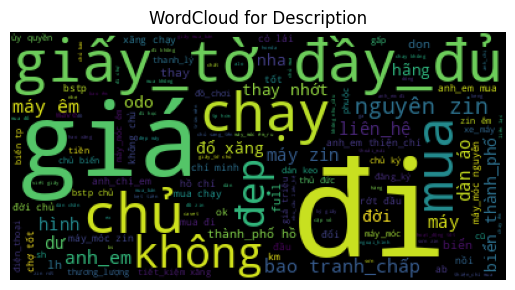

In [ ]:
wc = WordCloud().generate(content)
plt.imshow(wc)
plt.axis('off')
plt.title('WordCloud for Description')
plt.show()

In [ ]:
content = ' '.join(data['title_cleaned'])

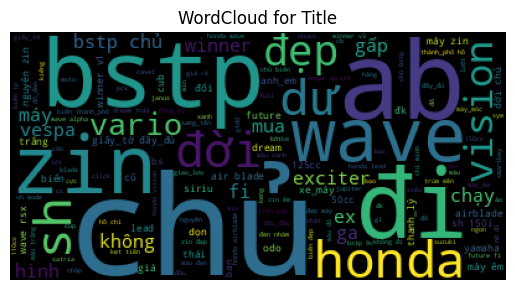

In [ ]:
wc = WordCloud().generate(content)
plt.imshow(wc)
plt.axis('off')
plt.title('WordCloud for Title')
plt.show()

In [ ]:
data['content'] = data['description_cleaned'] + ' ' + data['title_cleaned']

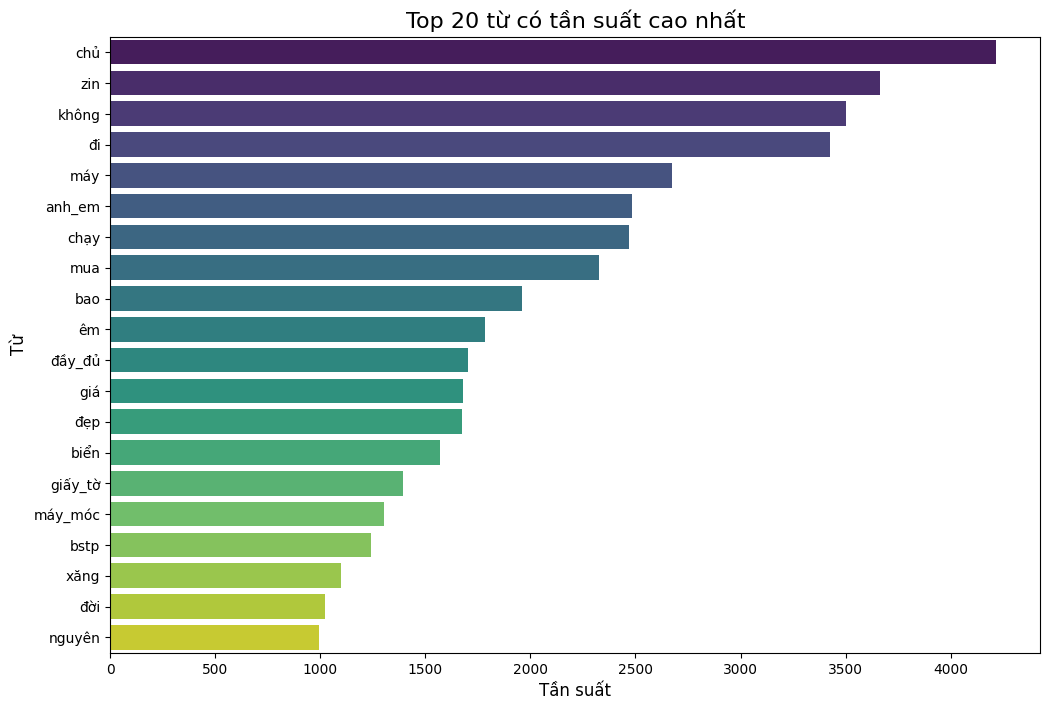

In [ ]:
word_counter = CountVectorizer()
word_counts_matrix = word_counter.fit_transform(data['content'])

word_frequencies = pd.DataFrame({
    'term': word_counter.get_feature_names_out(),
    'frequency': word_counts_matrix.sum(axis=0).getA1()
})

top_words = word_frequencies.sort_values(by='frequency', ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x='frequency', y='term', data=top_words, palette='viridis')
plt.title('Top 20 từ có tần suất cao nhất', fontsize=16)
plt.xlabel('Tần suất', fontsize=12)
plt.ylabel('Từ', fontsize=12)
plt.show()

# Recommendation using cosine similarity

In [ ]:

tfidf_vectorizer = TfidfVectorizer(
    min_df=2,      # Bỏ qua các từ xuất hiện ít hơn 5 lần
    max_df=0.8,    # Bỏ qua các từ xuất hiện trong hơn 80% tài liệu (từ quá chung)
    ngram_range=(1, 2) # Xem xét cả từ đơn (unigram) và cụm 2 từ (bigram)
)

print("Bắt đầu huấn luyện Model 1")
start_time_model_1 = time.time()

tfidf_matrix = tfidf_vectorizer.fit_transform(data['content'])

cosine_score = cosine_similarity(tfidf_matrix)

end_time_model_1 = time.time()
train_time_model_1 = end_time_model_1 - start_time_model_1
print(f"--- Hoàn thành Model 1 (Sklearn) ---")
print(f"Shape của TF-IDF matrix: {tfidf_matrix.shape}")
print(f"Thời gian huấn luyện: {train_time_model_1:.4f} giây")
df_cosine_score = pd.DataFrame(cosine_score)

Bắt đầu huấn luyện Model 1
--- Hoàn thành Model 1 (Sklearn) ---
Shape của TF-IDF matrix: (7204, 22707)
Thời gian huấn luyện: 6.1783 giây


In [ ]:
def choose_best_k_recommend(k:int, df_cosine_score:pd.DataFrame, id:int):
  df_recommend = df_cosine_score[[id-1]]
  lst_best_recommend = df_recommend.sort_values(by = id - 1, ascending = False).index

  lst_best_recommend = list(lst_best_recommend)

  return list(lst_best_recommend)[:k]

In [ ]:
best_k_indexes = choose_best_k_recommend(15, df_cosine_score, 3)
best_k_indexes

[2,
 1852,
 3021,
 3290,
 2115,
 660,
 7039,
 2496,
 5405,
 6139,
 3289,
 3376,
 4649,
 6719,
 6122]

In [ ]:
# def recommend(data, df_cosine_score, user_id, k):
#   best_k_indexes = choose_best_k_recommend(k, df_cosine_score, user_id)
#   print(f'Content of user id {user_id}: \n')
#   print(data.loc[user_id, 'content'])
#   print(50*'=')
#   print(f'Top {k} that should recommend to user id {user_id}')
#   return data.loc[best_k_indexes].iloc[1:]

# df_result = recommend(data, df_cosine_score, 2, 10)
# df_result

def recommend(data, df_cosine_score, id, k, verboose = True):
    best_k_indexes = choose_best_k_recommend(k, df_cosine_score, id)

    if verboose:
      print(f'Content of id {id}: \n')
      print(data.loc[id - 1, 'content'])
      print(50*'=')

      print(f'Top {k} that should recommend to user id {id}')

    # Lấy điểm cosine tương ứng
    cosine_scores = df_cosine_score.loc[id - 1, best_k_indexes]

    # Tạo DataFrame kết quả kèm score
    result = data.loc[best_k_indexes].copy()
    result['cosine_score'] = cosine_scores.values

    return result.iloc[1:]   # bỏ user chính nếu choose_best_k có chứa self

df_result = recommend(data, df_cosine_score, 3, 10)
df_result

Content of id 3: 

chủ vision phiên_bản thể_thao 2023 đen mua hãng 10 2023 bảo_dưỡng đầy_đủ gia_đình đi giữ_gìn độ lên_đèn demi led audi a7 đèn hậu led audi a7 giá thị_trường 5tr nguyên đèn zin liên_hệ chủ 09xau xau sáu cc vision thể_thao 2023 đen đèn demi audi a7
Top 10 that should recommend to user id 3


,id,title,description,Dòng xe,description_cleaned,title_cleaned,content,cosine_score
1852,1853,wave anpha bstp 9c,Wave anpha dàn áo zx trùng màu cavet bstp 9c n...,Wave,wave anpha dàn áo zx trùng màu cavet bstp 9c c...,wave anpha bstp 9c,wave anpha dàn áo zx trùng màu cavet bstp 9c c...,0.284742
3021,3022,Cần Bán Xe Wave RS 2011,© Tôi cần bán chiếc xe Wave RS đăng ký 2011 Tạ...,Wave,wave rs đăng_ký 2011 khánh hoà đi mua thay nhớ...,wave rs 2011,wave rs đăng_ký 2011 khánh hoà đi mua thay nhớ...,0.216346
3290,3291,Bán xe Nouvo như hình,"Do ko chạy nữa xe trước kia chở gạo ,nước mạnh...",Nouvo,không chạy chở gạo nhu_cầu inbox,nouvo hình,không chạy chở gạo nhu_cầu inbox nouvo hình,0.178516
2115,2116,xe dư cần bán,"Xe dư e cần thanh lý, giấy tờ đầy đủ.",Nouvo,dư thanh_lý giấy_tờ đầy_đủ,dư,dư thanh_lý giấy_tờ đầy_đủ dư,0.161540
660,661,Vespa GTS 125cc,"Để chật nhà nên bán Vespa GTS 125 2007,xe như ...",GTS,chật vespa gts 125 2007 hình lên_đèn led mặt_n...,vespa gts 125cc,chật vespa gts 125 2007 hình lên_đèn led mặt_n...,0.156669
7039,7040,Yamaha NVX 125 bản khóa Smartkey bsptp 51 HCM,"Xe biển số 51 tp HCM \nXe không chính chủ,Biển...",Nvx,biển 51 tp_hcm không chủ biển nút đẹp xe_máy_m...,yamaha nvx 125 khóa smartkey bsptp 51 hcm,biển 51 tp_hcm không chủ biển nút đẹp xe_máy_m...,0.151100
2496,2497,Yamaha no LX giấy tờ đầy đủ,Xe như hình giấy tờ đầy đủ bao tranh chấp \nĐè...,Nouvo,hình giấy_tờ đầy_đủ bao tranh_chấp đèn đề đầy_...,yamaha no lx giấy_tờ đầy_đủ,hình giấy_tờ đầy_đủ bao tranh_chấp đèn đề đầy_...,0.143931
5405,5406,Winner bs63 9 chủ,Winner 2019 Bs63 9 chũ. xe leng keng. Máy mạnh...,Winner,winner 2019 bs63 chũ leng_keng máy giá 16x win...,winner bs63 chủ,winner 2019 bs63 chũ leng_keng máy giá 16x win...,0.142379
6139,6140,BÁN XE,Xe chính chủ\nGặp mặt tại Xã Bình Hưng Huyện B...,Future,chủ gặp_mặt xã bình hưng huyện bình_chánh hẻm ...,,chủ gặp_mặt xã bình hưng huyện bình_chánh hẻm ...,0.141999


In [ ]:
with open('/content/drive/MyDrive/DL07_K308_PhamNamAn_CaoThanhBang/Project_2/xe_cosine_sim.pkl', 'wb') as f:
    pickle.dump(cosine_score, f)

with open('/content/drive/MyDrive/DL07_K308_PhamNamAn_CaoThanhBang/Project_2/xe_cosine_sim.pkl', 'rb') as f:
    cosine_sim_new = pickle.load(f)


In [ ]:
df_cosine_new = pd.DataFrame(cosine_sim_new)

In [ ]:
df_result = recommend(data, df_cosine_new, 3, 10)
df_result

Content of id 3: 

chủ vision phiên_bản thể_thao 2023 đen mua hãng 10 2023 bảo_dưỡng đầy_đủ gia_đình đi giữ_gìn độ lên_đèn demi led audi a7 đèn hậu led audi a7 giá thị_trường 5tr nguyên đèn zin liên_hệ chủ 09xau xau sáu cc vision thể_thao 2023 đen đèn demi audi a7
Top 10 that should recommend to user id 3


,id,title,description,Dòng xe,description_cleaned,title_cleaned,content,cosine_score
1852,1853,wave anpha bstp 9c,Wave anpha dàn áo zx trùng màu cavet bstp 9c n...,Wave,wave anpha dàn áo zx trùng màu cavet bstp 9c c...,wave anpha bstp 9c,wave anpha dàn áo zx trùng màu cavet bstp 9c c...,0.308978
3290,3291,Bán xe Nouvo như hình,"Do ko chạy nữa xe trước kia chở gạo ,nước mạnh...",Nouvo,không chạy chở gạo nhu_cầu inbox,nouvo hình,không chạy chở gạo nhu_cầu inbox nouvo hình,0.267557
660,661,Vespa GTS 125cc,"Để chật nhà nên bán Vespa GTS 125 2007,xe như ...",GTS,chật vespa gts 125 2007 hình lên_đèn led mặt_n...,vespa gts 125cc,chật vespa gts 125 2007 hình lên_đèn led mặt_n...,0.263403
4649,4650,CẦN BÁN BMW G310R,Tình trạng xe còn tốt \nPhù hợp với mọi địa hình,Dòng khác,tốt địa_hình,bmw g310r,tốt địa_hình bmw g310r,0.249265
5405,5406,Winner bs63 9 chủ,Winner 2019 Bs63 9 chũ. xe leng keng. Máy mạnh...,Winner,winner 2019 bs63 chũ leng_keng máy giá 16x win...,winner bs63 chủ,winner 2019 bs63 chũ leng_keng máy giá 16x win...,0.239901
3289,3290,AB 2011 úp thái xe đẹp keng máy móc êm ru,AB 2011 xe đẹp keng máy móc bao êm lên thái sẵ...,Air Blade,ab 2011 đẹp keng máy_móc bao êm thái sẵn anh_e...,ab 2011 úp thái đẹp keng máy_móc êm_ru,ab 2011 đẹp keng máy_móc bao êm thái sẵn anh_e...,0.217835
5257,5258,ex zing đầu nồi chưa rớt,Xe k trầy không bể máy im có giây cưa hàng bao...,Exciter,không trầy không bể máy im giây cưa hàng bao t...,ex zing đầu nồi rớt,không trầy không bể máy im giây cưa hàng bao t...,0.207883
7039,7040,Yamaha NVX 125 bản khóa Smartkey bsptp 51 HCM,"Xe biển số 51 tp HCM \nXe không chính chủ,Biển...",Nvx,biển 51 tp_hcm không chủ biển nút đẹp xe_máy_m...,yamaha nvx 125 khóa smartkey bsptp 51 hcm,biển 51 tp_hcm không chủ biển nút đẹp xe_máy_m...,0.207324
3376,3377,Xe Honda PS,Xe PS đời 2008 màu xanh đá xài rồi zin chưa bu...,PS,ps đời 2008 màu xanh đá xài zin bung máy đi ch...,honda ps,ps đời 2008 màu xanh đá xài zin bung máy đi ch...,0.197553


## Input text from user and recommend (feature)

In [ ]:
data.shape

(7204, 7)

In [ ]:
# # Ngoài dataset
# def out_recommend_motorbike(text = '', top_k=5, data = None):
#   print("Input:", text)
#   text = preprocess_text(text)
#   df_sample = pd.DataFrame({
#       'content' : [text]
#   })
#   text_feat = vectorizer.transform(df_sample['content'])
#   cosine_score = cosine_similarity(tfidf_matrix, text_feat)
#   df_result = pd.DataFrame(cosine_score)
#   best_indexes = list(df_result.sort_values(by = 0, ascending = False).index)

#   best_k_index = best_indexes[:top_k]
#   return data.iloc[best_k_indexes, :]

# out_recommend_motorbike("T cần mua 1 chiếc vespa### nguyên zin 💖", 5, data)

# Ngoài dataset
def out_recommend_motorbike(text='', top_k=5, data=None):
    print("Input:", text)

    # Preprocess
    text = preprocess_text(text)
    df_sample = pd.DataFrame({'content': [text]})

    # Transform text
    text_feat = tfidf_vectorizer.transform(df_sample['content'])

    # Compute cosine similarity
    cosine_score = cosine_similarity(tfidf_matrix, text_feat).flatten()

    # Convert to DataFrame
    df_result = pd.DataFrame({
        "cosine_score": cosine_score
    })

    # Sort by cosine score
    best_indexes = df_result.sort_values(by="cosine_score", ascending=False).index
    best_k_indexes = best_indexes[:top_k]

    # Extract rows
    result = data.iloc[best_k_indexes, :].copy()

    # Thêm cột cosine score tương ứng
    result["cosine_score"] = df_result.loc[best_k_indexes, "cosine_score"].values

    return result
out_recommend_motorbike("T cần mua 1 chiếc vespa### nguyên zin 💖", 5, data)



Input: T cần mua 1 chiếc vespa### nguyên zin 💖


,id,title,description,Dòng xe,description_cleaned,title_cleaned,content,cosine_score
1507,1508,BÁN GẤP XE VESPA NOTTE NGUYÊN ZIN CÁ NHÂN,Cần tiền bán gâp xe vespa notte 2019 nguyên zi...,Vespa,tiền gâp vespa notte 2019 nguyên zin bstp 042....,gấp vespa notte nguyên zin,tiền gâp vespa notte 2019 nguyên zin bstp 042....,0.448626
4554,4555,Xe Vespa,Cần bán xe vespa sản xuất năm 2013 xe máy móc ...,Vespa,vespa sản_xuất 2013 xe_máy_móc nguyên zin đẹp ...,vespa,vespa sản_xuất 2013 xe_máy_móc nguyên zin đẹp ...,0.416712
4008,4009,Xe EX nguyên zin,"Xe đã qua sử dụng, nguyên zin bao teat\n\nLiên...",Exciter,nguyên zin bao_teat liên_hệ trao_đổi,ex nguyên zin,nguyên zin bao_teat liên_hệ trao_đổi ex nguyên...,0.381219
4897,4898,Mô tô,"❤️‍🔥❤️‍🔥❤️‍🔥❤️‍🔥\nR15V3\nXe nguyên rin, thơm p...",Dòng khác,yêu yêu yêu yêu r15v3 nguyên rin thơm_phức giấ...,mô_tô,yêu yêu yêu yêu r15v3 nguyên rin thơm_phức giấ...,0.377352
6204,6205,🌷Bán ex ctđ 2010 full mới 100% 1s9A❤️,💖Xe mới dọn full từ cây suờn 100%\nChưa đi hết...,Exciter,yêu dọn full suờn 100 đi bình xăng full salaya...,ex ctđ 2010 full 100 1s9a yêu,yêu dọn full suờn 100 đi bình xăng full salaya...,0.371430


# Recommendation using Genism

In [ ]:
content_gensism = [[w for w in text.split()] for text in data['content']]

In [ ]:
content_gensism[:1]

[['vespa',
  'sprint',
  '125cc',
  'mua',
  'topcom',
  '01',
  '2024',
  'chủ',
  'chạy',
  '14.000',
  'km',
  'giá',
  '66tr',
  'trả_lời',
  'nhắn',
  'zalo',
  'công_chứng',
  'hợp_đồng',
  'mua_bán',
  'vespa',
  'sprint',
  '125cc',
  '2024',
  'xanh',
  'dương',
  'đẹp',
  '95']]

In [ ]:
i = 1
print(data['content'][i])
print("=========")
content_gensism[i]

_bán sh 150i thắng abs 2019 xám bạc úp team xám xi_măng _xe kỹ đi chủ biển thành_phố _xe keng máy_móc nguyên zin êm bốc anh_em test thoải_mái _mua sang_tên ký giấy nốt_nhạc _xem tân sơn nhì tân sơn nhì tân_phú sh 150i thắng abs 2019 bstp chủ


['_bán',
 'sh',
 '150i',
 'thắng',
 'abs',
 '2019',
 'xám',
 'bạc',
 'úp',
 'team',
 'xám',
 'xi_măng',
 '_xe',
 'kỹ',
 'đi',
 'chủ',
 'biển',
 'thành_phố',
 '_xe',
 'keng',
 'máy_móc',
 'nguyên',
 'zin',
 'êm',
 'bốc',
 'anh_em',
 'test',
 'thoải_mái',
 '_mua',
 'sang_tên',
 'ký',
 'giấy',
 'nốt_nhạc',
 '_xem',
 'tân',
 'sơn',
 'nhì',
 'tân',
 'sơn',
 'nhì',
 'tân_phú',
 'sh',
 '150i',
 'thắng',
 'abs',
 '2019',
 'bstp',
 'chủ']

In [ ]:
#Remove leading '_'
cleaned_content_genism = [
    [w.lstrip('_') for w in tokens]
    for tokens in content_gensism
]

In [ ]:
cleaned_content_genism[1]

['bán',
 'sh',
 '150i',
 'thắng',
 'abs',
 '2019',
 'xám',
 'bạc',
 'úp',
 'team',
 'xám',
 'xi_măng',
 'xe',
 'kỹ',
 'đi',
 'chủ',
 'biển',
 'thành_phố',
 'xe',
 'keng',
 'máy_móc',
 'nguyên',
 'zin',
 'êm',
 'bốc',
 'anh_em',
 'test',
 'thoải_mái',
 'mua',
 'sang_tên',
 'ký',
 'giấy',
 'nốt_nhạc',
 'xem',
 'tân',
 'sơn',
 'nhì',
 'tân',
 'sơn',
 'nhì',
 'tân_phú',
 'sh',
 '150i',
 'thắng',
 'abs',
 '2019',
 'bstp',
 'chủ']

In [ ]:
dictionary = corpora.Dictionary(cleaned_content_genism)

In [ ]:
dictionary.token2id

{'01': 0,
 '125cc': 1,
 '14.000': 2,
 '2024': 3,
 '66tr': 4,
 '95': 5,
 'chạy': 6,
 'chủ': 7,
 'công_chứng': 8,
 'dương': 9,
 'giá': 10,
 'hợp_đồng': 11,
 'km': 12,
 'mua': 13,
 'mua_bán': 14,
 'nhắn': 15,
 'sprint': 16,
 'topcom': 17,
 'trả_lời': 18,
 'vespa': 19,
 'xanh': 20,
 'zalo': 21,
 'đẹp': 22,
 '150i': 23,
 '2019': 24,
 'abs': 25,
 'anh_em': 26,
 'biển': 27,
 'bstp': 28,
 'bán': 29,
 'bạc': 30,
 'bốc': 31,
 'giấy': 32,
 'keng': 33,
 'ký': 34,
 'kỹ': 35,
 'máy_móc': 36,
 'nguyên': 37,
 'nhì': 38,
 'nốt_nhạc': 39,
 'sang_tên': 40,
 'sh': 41,
 'sơn': 42,
 'team': 43,
 'test': 44,
 'thoải_mái': 45,
 'thành_phố': 46,
 'thắng': 47,
 'tân': 48,
 'tân_phú': 49,
 'xe': 50,
 'xem': 51,
 'xi_măng': 52,
 'xám': 53,
 'zin': 54,
 'êm': 55,
 'úp': 56,
 'đi': 57,
 '09xau': 58,
 '10': 59,
 '2023': 60,
 '5tr': 61,
 'a7': 62,
 'audi': 63,
 'bảo_dưỡng': 64,
 'cc': 65,
 'demi': 66,
 'gia_đình': 67,
 'giữ_gìn': 68,
 'hãng': 69,
 'hậu': 70,
 'led': 71,
 'liên_hệ': 72,
 'lên_đèn': 73,
 'phiên_bản': 7

In [ ]:
feature_cnt = len(dictionary.token2id)
feature_cnt

10965

In [ ]:
corpus = [dictionary.doc2bow(text) for text in cleaned_content_genism]
corpus[1]

[(7, 2),
 (13, 1),
 (23, 2),
 (24, 2),
 (25, 2),
 (26, 1),
 (27, 1),
 (28, 1),
 (29, 1),
 (30, 1),
 (31, 1),
 (32, 1),
 (33, 1),
 (34, 1),
 (35, 1),
 (36, 1),
 (37, 1),
 (38, 2),
 (39, 1),
 (40, 1),
 (41, 2),
 (42, 2),
 (43, 1),
 (44, 1),
 (45, 1),
 (46, 1),
 (47, 2),
 (48, 2),
 (49, 1),
 (50, 2),
 (51, 1),
 (52, 1),
 (53, 2),
 (54, 1),
 (55, 1),
 (56, 1),
 (57, 1)]

In [ ]:
print("Bắt đầu huấn luyện Model 2")
start_time_model_2 = time.time()

tfidf = models.TfidfModel(corpus)

index = similarities.SparseMatrixSimilarity(tfidf[corpus],
                                            num_features = feature_cnt)
similarities_df = pd.DataFrame(index)

end_time_model_2 = time.time()
train_time_model_2 = end_time_model_2 - start_time_model_2
print(f"--- Hoàn thành Model 2 (Gensim) ---")
print(f"Thời gian huấn luyện: {train_time_model_2:.4f} giây")

Bắt đầu huấn luyện Model 2
--- Hoàn thành Model 2 (Gensim) ---
Thời gian huấn luyện: 59.9871 giây


In [ ]:
id = 0
customer_search = cleaned_content_genism[id]
top5 = similarities_df.loc[id].drop(id, errors='ignore').nlargest(5)
top5

,0
64,0.343383
4722,0.321855
4990,0.296955
2161,0.272937
1472,0.272577


In [ ]:
# Nội trong dataset.
def in_recommend_motorbike(i, top_k=5, verboose = True):
  text = data['content'][i-1]
  if verboose:
    print("Input:", text)
  top_similarity = similarities_df.loc[i-1].drop(i-1, errors='ignore').nlargest(top_k)
  if verboose:
    print("Top similarity", top_similarity)
  return data['content'].iloc[top_similarity.index.tolist()]


In [ ]:
in_recommend_motorbike(1)

Input: vespa sprint 125cc mua topcom 01 2024 chủ chạy 14.000 km giá 66tr trả_lời nhắn zalo công_chứng hợp_đồng mua_bán vespa sprint 125cc 2024 xanh dương đẹp 95
Top similarity 64      0.343383
4722    0.321855
4990    0.296955
2161    0.272937
1472    0.272577
Name: 0, dtype: float32


,content
64,hư_hỏng mua hãng 2024 liên_hệ ga janus màu xan...
4726,đổi gấp vespa sprint 150 chủ 2020 vespa sprint...
4994,vespa sprint 2015 sơn đổi màu full phụ_kiện th...
2163,ab 125cc chủ mua 10 2024 99 chủ biển thành_phố...
1474,vespa sprint 125 đklđ 2022 giá 55 triệu q10 ve...


In [ ]:
# Ngoài dataset
def out_recommend_motorbike(text, top_k=5):
  print("Input:", text)
  # 1. Đọc text và preprocess
  text = preprocess_text(text)
  tokens = text.split()
  # 2. Xây dựng similarities
  bow_vec = dictionary.doc2bow(tokens)
  tfidf_vec = tfidf[bow_vec]
  sims = index[tfidf_vec]
  # 3. Đưa recommendations
  top_idx = np.argsort(-sims)[:top_k]
  return data['content'].iloc[top_idx]




In [ ]:
user_search = 'Wave màu trắng'
out_recommend_motorbike(user_search)

Input: Wave màu trắng


,content
6046,wave mua màu trắng 2023 dọn màu xanh
487,chủ màu trắng liên_hệ điện_thoại chaly honda m...
3765,thanh_lý sh 150i màu trắng máy êm đẹp đời 2014...
6382,sh 150i rớt đầu màu trắng sh rớt đầu màu trắng
6719,vision trắng


# Evaluate 2 models

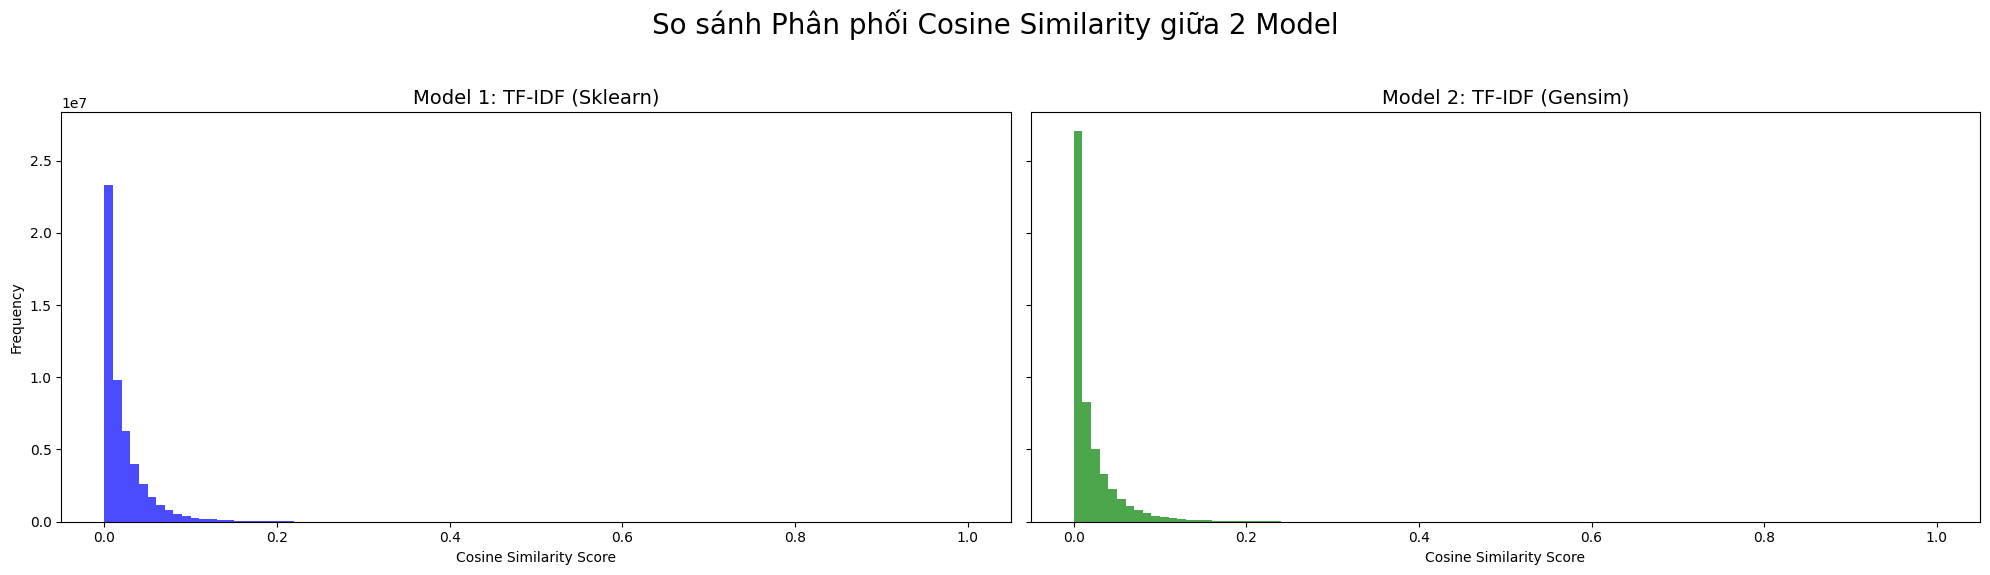

In [ ]:

def get_scores_no_diagonal(matrix):
    if isinstance(matrix, pd.DataFrame):
        matrix = matrix.values

    all_scores = matrix.flatten()
    scores_no_diag = all_scores[all_scores < 0.9999] # Bỏ giá trị 1.0
    return scores_no_diag

# Lấy điểm số của cả 3 model
scores_model_1 = get_scores_no_diagonal(cosine_score)
scores_model_2 = get_scores_no_diagonal(similarities_df)

# --- Vẽ biểu đồ ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

# Biểu đồ 1: TF-IDF (Sklearn)
ax1.hist(scores_model_1, bins=100, color='blue', alpha=0.7, range=(0,1))
ax1.set_title('Model 1: TF-IDF (Sklearn)', fontsize=14)
ax1.set_xlabel('Cosine Similarity Score')
ax1.set_ylabel('Frequency')

# Biểu đồ 2: TF-IDF (Gensim)
ax2.hist(scores_model_2, bins=100, color='green', alpha=0.7, range=(0,1))
ax2.set_title('Model 2: TF-IDF (Gensim)', fontsize=14)
ax2.set_xlabel('Cosine Similarity Score')

# Biểu đồ 3: LSA

plt.suptitle('So sánh Phân phối Cosine Similarity giữa 2 Model', fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Không có sự khác biệt quá nhiều về phân phối 2 mô hình

In [ ]:
def calculate_precision_at_k(goc_item_id, recommended_indices, k=5):
    """
    Tính Precision@k cho 1 item dựa trên cột 'Hãng xe'.
    Trả về số trong [0,1], trả về 0 nếu không match, lỗi, hoặc item không hợp lệ.
    """
    try:
        goc_brand = data.iloc[goc_item_id]['Dòng xe']
    except Exception:
        return 0  # lỗi index → coi như không match

    # Bỏ qua item không hợp lệ
    if pd.isna(goc_brand) or goc_brand == 'Khác':
        print("hi")
        return 0

    # Lấy top-k index
    top_k_indices = recommended_indices[:k]
    if len(top_k_indices) == 0:
        print("hi1")
        return 0

    try:
        recommended_brands = data.loc[top_k_indices, 'Dòng xe']
    except Exception:
        print("allo")
        return 0

    # Số lượng match
    correct_count = (recommended_brands == goc_brand).sum()

    # Precision@k
    return correct_count / k


In [ ]:
k = 15

# --- Model 1: Sklearn ---
total_precision_model_1 = 0
items_evaluated_1 = 0

for item_id in range(1, 50):
    try:
        indices_model_1 = recommend(data, df_cosine_score, item_id, k, False).index.tolist()
    except Exception:
        indices_model_1 = []

    p_at_k = calculate_precision_at_k(item_id, indices_model_1, k=k)
    total_precision_model_1 += p_at_k
    items_evaluated_1 += 1

mp_at_5_model_1 = total_precision_model_1 / items_evaluated_1 if items_evaluated_1 > 0 else 0
print(f"Model 1 (Sklearn TF-IDF) - MP@5: {mp_at_5_model_1:.4f}")


# --- Model 2: Gensim ---
total_precision_model_2 = 0
items_evaluated_2 = 0

for item_id in range(1, 50):
    try:
        indices_model_2 = in_recommend_motorbike(item_id, top_k=k, verboose = False).index.tolist()
    except Exception:
        indices_model_2 = []

    p_at_k = calculate_precision_at_k(item_id, indices_model_2, k=k)
    total_precision_model_2 += p_at_k
    items_evaluated_2 += 1

mp_at_5_model_2 = total_precision_model_2 / items_evaluated_2 if items_evaluated_2 > 0 else 0
print(f"Model 2 (Gensim TF-IDF) - MP@5: {mp_at_5_model_2:.4f}")


Model 1 (Sklearn TF-IDF) - MP@5: 0.0381
Model 2 (Gensim TF-IDF) - MP@5: 0.0327


Precision@K không thật sự phản ảnh độ hiệu quả của recommendation, vì không có groundtruth cụ thế nào để so sánh, việc so sánh hiệu quả tự cho rằng đúng theo dòng xe, nhưng dòng xe và description và title cũng có sự khác biệt vì có nhiều dòng nên chỉ mang tính chất tham khảo